In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Numerische Verfahren zum Lösen von ODEs (=gewöhnliche Differentialgleichungen)

## Teil 1: $y' = f(t)$
**Beispiel:** $y' = \frac{1}{\tan(t)}$

**Frage 1:** Wie löst man diese DGL?

### Programmierteil 1: Wie plottet man die Funktion (im Bereich $(0,\pi/2)$) ?

In [3]:
#Plot initiieren: Als Größe empfiehlt sich (8,6) oder (10,6)
plt.figure(figsize=(8, 6))
#Bereitstellen der Liste der t-Werte:
#Zur Definition der Liste der t-Werte möchte ich sicherstellen, dass 0 und pi/2 nicht enthalten sind.
#Deshalb benutze ich np.arange
t=np.arange()
#Bereitstellen der Liste der zug. Funktionswerte f:
f=
#wir tragen immer Listen gleicher Längen gegeneinander auf. Python verbindet die so generierten Punkte automatisch
plt.plot(t,f)
# Beispiel an Style-Varianten:
# label=r"$1/tan(t)$" (das r erlaubt LaTex-Code), linestyles="--", marker='o', color="green", linewidth=2

#nachfolgend noch die
plt.xlabel('Zeit t')
plt.ylabel('H')
plt.legend()
plt.grid()
plt.show()

NameError: name 't' is not defined

<Figure size 800x600 with 0 Axes>

**Frage 2:** An welche numerischen Verfahren zur Approximation des Integrals erinnern wir uns?

*   Listeneintrag
*   Listeneintrag

## Teil 2: Allg. ODE 1, Ordnung $y' = f(t,y)$

### Programmierteil 2: Plots können viel allgemeiner sein, als reine Funktionsplots. Als Beispiel:


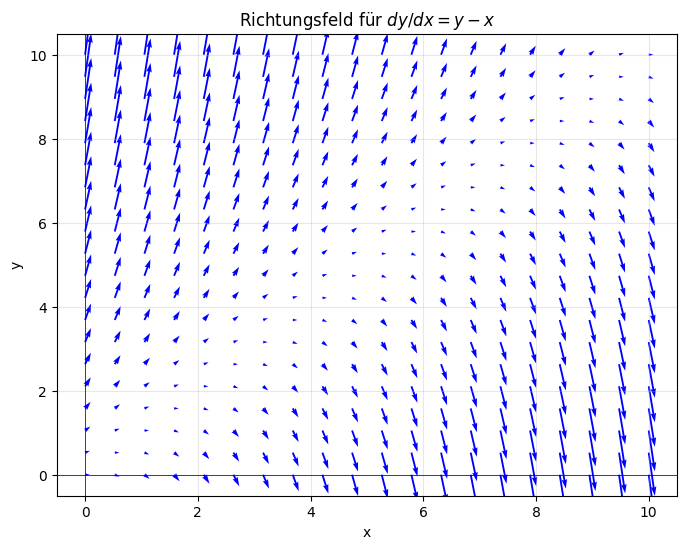

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# DGL definieren
def dydx(x, y):
    return y - x

# Grid erzeugen
x = np.linspace(0, 10, 20)
y = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x, y)

# Steigung an jedem Punkt berechnen
U = np.ones_like(X)  # Horizontale Komponente (arbitrary, normalized to 1)
V = dydx(X, Y)  # Vertikale Komponente ist die Steigung

# Plot des Richtungsfeldes
plt.figure(figsize=(8, 6))
plt.quiver(X, Y, U, V, color='blue', angles='xy')
plt.title("Richtungsfeld für $dy/dx = y - x$")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.show()



### Programmierteil des Heun-Verfahrens
Das Heun-Verfahren ist wie folgt definiert
$$ y_{n+1} = y_n + \frac{h}{2}\cdot \left( f(t_n,y_n) + f(t_n+h, y_n + h \cdot f(t_n, y_n)) \right) $$

**Frage 3:** Wie implementiert man das Heun-Verfahren in Python?


In [14]:
# Implementierung des Heun-Verfahrens

def H(f,t,y0):
    y = [y0]
    for n in range(0,len(t)-1):
        z_n = y[n]+ (t[n+1]-t[n])*f(t[n],y[n])
        y_new = y[n] + (t[n+1]-t[n])/2 * (f(t[n],y[n]) + f(t[n+1],z_n))
        y.append(y_new)
    return t,y

def f(t,y):
    return y - t
t = np.linspace(0,2,100)
y0 = 3

H(f,t,y0)

(array([0.        , 0.02020202, 0.04040404, 0.06060606, 0.08080808,
        0.1010101 , 0.12121212, 0.14141414, 0.16161616, 0.18181818,
        0.2020202 , 0.22222222, 0.24242424, 0.26262626, 0.28282828,
        0.3030303 , 0.32323232, 0.34343434, 0.36363636, 0.38383838,
        0.4040404 , 0.42424242, 0.44444444, 0.46464646, 0.48484848,
        0.50505051, 0.52525253, 0.54545455, 0.56565657, 0.58585859,
        0.60606061, 0.62626263, 0.64646465, 0.66666667, 0.68686869,
        0.70707071, 0.72727273, 0.74747475, 0.76767677, 0.78787879,
        0.80808081, 0.82828283, 0.84848485, 0.86868687, 0.88888889,
        0.90909091, 0.92929293, 0.94949495, 0.96969697, 0.98989899,
        1.01010101, 1.03030303, 1.05050505, 1.07070707, 1.09090909,
        1.11111111, 1.13131313, 1.15151515, 1.17171717, 1.19191919,
        1.21212121, 1.23232323, 1.25252525, 1.27272727, 1.29292929,
        1.31313131, 1.33333333, 1.35353535, 1.37373737, 1.39393939,
        1.41414141, 1.43434343, 1.45454545, 1.47

Als nächstes testen wir das eben berechnete Heun-Verfahren für das AWP
$$ y ' = y - t, ~ y(0) = 3 $$
Zuerst benennen wir die Ausgabe von `H(f,t,y0)` als `t_werte` bzw `y_werte`.
Diese plotten wir dann gegeneinander in dem Schaubild, das auch das Richtungsfeld der DGL enthält.

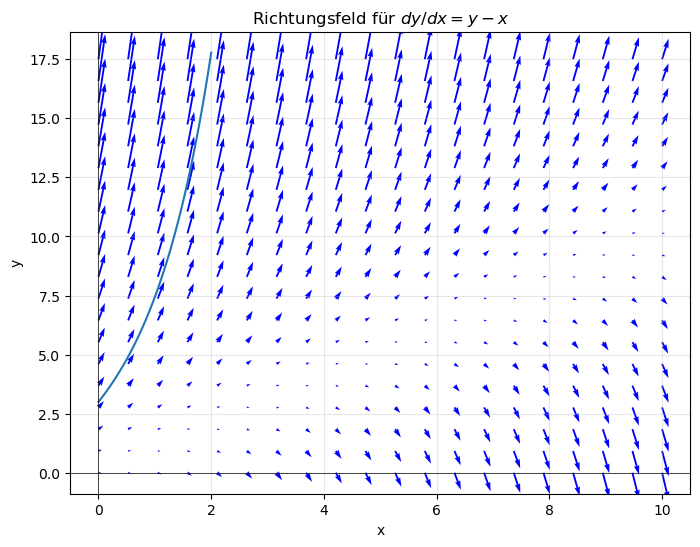

In [17]:
t_werte,y_werte=H(f,t,y0)


# DGL definieren
def dydx(x, y):
    return y - x

# Grid erzeugen
x = np.linspace(0, 10, 20)
y = np.linspace(0, 17.5, 20)
X, Y = np.meshgrid(x, y)

# Steigung an jedem Punkt berechnen
U = np.ones_like(X)  # Horizontale Komponente (arbitrary, normalized to 1)
V = dydx(X, Y)  # Vertikale Komponente ist die Steigung

# Plot des Richtungsfeldes
plt.figure(figsize=(8, 6))
plt.quiver(X, Y, U, V, color='blue', angles='xy')
plt.title("Richtungsfeld für $dy/dx = y - x$")
plt.plot(t_werte,y_werte)
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.show()